<a href="https://colab.research.google.com/github/marescost4/Mariane-David-Fillipy/blob/main/tarefa13_Python_Ciencias_Biologicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Bioestatística - Tarefa 13


*   David Souza 16965966
*   Fillipy Leal 17097358
*   Mariane Santana 16890981

​Base de dados: *Trait variation and plant performance: Interactive effects of diversity and spatial patterning of plants across environmental conditions.*

​DOI / Link: https://doi.org/10.5061/dryad.w6m905r2n

​Instituição responsável: Dryad Digital Repository / Autores da publicação original.

​Data de Acesso: 03 de Outubro de 2026.

​Arquivo Utilizado: RawTraitsData.xlsx (proveniente de RawTraitsData.csv).

​Cada linha representa folha individual de planta (leaf.id dentro de cada parcela plot.id).

​Significado de cada linha: Medições morfológicas e fisiológicas de uma única amostra de folha.

Variáveis utilizadas:

- `plot.id`: identificação da parcela;
- `species_identity`: espécie da folha analisada;
- `environmental_context`: condição ambiental;
- `mix`: monocultura ou mistura;
- `species_richness`: número de espécies por parcela;
- `SPAD (SPAD unit)`: teor relativo de clorofila medido por medidor SPAD;
- `spatial_pattern`: padrão espacial das plantas.

Foram selecionados apenas:

- ambiente `ambient`;
- parcelas em `monoculture`;
- espécies *Portulaca grandiflora* (P) e *Zinnia elegans* (Z).

Essa seleção permite comparar duas espécies sob condições experimentais semelhantes.
.

​Tratamento de dados ausentes: A base contém 3.220 observações sem valores ausentes nas variáveis morfológicas.

### Sumário

1. Introdução
2. Distribuição Normal
3. Distribuição t de Student
4. Distribuição qui-quadrado
5. Distribuição F de Fisher
6. Comparação entre as distribuições
7. Conclusão
8. Referências

## 1 -  Introdução

Neste trabalho utilizamos uma base de dados real disponibilizada pelo repositório Dryad. O conjunto de dados apresenta características foliares de três espécies de plantas: *Portulaca grandiflora*, *Trifolium repens* e *Zinnia elegans*.

A variável escolhida para a análise foi o SPAD, uma medida relacionada ao teor relativo de clorofila das folhas, expressa em unidades SPAD.

Para tornar a comparação mais controlada, foram selecionadas folhas de *Portulaca grandiflora* (P) e *Zinnia elegans* (Z), considerando apenas parcelas em condição de ambiente (`ambient`) e em monocultura (`monoculture`).



A pergunta biológica investigada é:

 > Em condições ambientais e em monocultura, a variabilidade do teor relativo de clorofila (SPAD) difere entre *Portulaca grandiflora* e *Zinnia elegans*?



Iremos utilizar como solicitado na tarefa  as distribuições Normal, t de Student, qui-quadrado e F de Fisher. É importante distinguir a medida biológica observada das estatísticas calculadas a partir da amostra. O valor de SPAD é uma medida realizada diretamente em uma folha, enquanto as estatísticas t, qui-quadrado e F são calculadas a partir de conjuntos de observações.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

df = pd.read_excel('RawTraitsData.xlsx')
print(f"Total de registros carregados: {len(df)}")
df.head()


Total de registros carregados: 3220


,plot.id,environmental_context,species_composition,species_identity,mix,species_richness,leaf.id,LA (cm2),SLA (cm2/g),LDMC (dry-weight/fresh-weight ratio),LT (cm),SPAD (SPAD unit),spatial_pattern
0,T101,ambient,P,P,monoculture,1,1,1.2439,210.830509,0.004743,1.7780,30.0,neg
1,T101,ambient,P,P,monoculture,1,2,1.3626,197.478261,0.005064,1.8034,18.9,neg
2,T101,ambient,P,P,monoculture,1,3,1.1808,236.160000,0.004234,1.7018,36.7,neg
3,T101,ambient,P,P,monoculture,1,4,1.5504,218.366197,0.004579,1.7780,22.3,neg
4,T101,ambient,P,P,monoculture,1,5,1.3750,319.767442,0.003127,1.7272,44.9,neg


In [ ]:
print("Colunas da base:")
print(df.columns.tolist())

print("\nNúmero de linhas e colunas:")
print(df.shape)

print("\nValores ausentes:")
display(df.isna().sum())

Colunas da base:
['plot.id', 'environmental_context', 'species_composition', 'species_identity', 'mix', 'species_richness', 'leaf.id', 'LA (cm2)', 'SLA (cm2/g)', 'LDMC (dry-weight/fresh-weight ratio)', 'LT (cm)', 'SPAD (SPAD unit)', 'spatial_pattern']

Número de linhas e colunas:
(3220, 13)

Valores ausentes:


,0
plot.id,0
environmental_context,0
species_composition,0
species_identity,0
mix,0
species_richness,0
leaf.id,0
LA (cm2),0
SLA (cm2/g),0
LDMC (dry-weight/fresh-weight ratio),0


In [ ]:
# Selecionando as condições desejadas

dados = df[
    (df["environmental_context"] == "ambient") &
    (df["mix"] == "monoculture") &
    (df["species_identity"].isin(["P", "Z"]))
].copy()

print("Número de observações selecionadas:", len(dados))

display(dados.head())

Número de observações selecionadas: 300


,plot.id,environmental_context,species_composition,species_identity,mix,species_richness,leaf.id,LA (cm2),SLA (cm2/g),LDMC (dry-weight/fresh-weight ratio),LT (cm),SPAD (SPAD unit),spatial_pattern
0,T101,ambient,P,P,monoculture,1,1,1.2439,210.830509,0.004743,1.7780,30.0,neg
1,T101,ambient,P,P,monoculture,1,2,1.3626,197.478261,0.005064,1.8034,18.9,neg
2,T101,ambient,P,P,monoculture,1,3,1.1808,236.160000,0.004234,1.7018,36.7,neg
3,T101,ambient,P,P,monoculture,1,4,1.5504,218.366197,0.004579,1.7780,22.3,neg
4,T101,ambient,P,P,monoculture,1,5,1.3750,319.767442,0.003127,1.7272,44.9,neg


In [ ]:
# Separando os valores de SPAD por espécie

P = dados.loc[
    dados["species_identity"] == "P",
    "SPAD (SPAD unit)"
].dropna()

Z = dados.loc[
    dados["species_identity"] == "Z",
    "SPAD (SPAD unit)"
].dropna()

print("Número de folhas de Portulaca grandiflora:", len(P))
print("Número de folhas de Zinnia elegans:", len(Z))

Número de folhas de Portulaca grandiflora: 150
Número de folhas de Zinnia elegans: 150


In [ ]:
resumo = dados.groupby("species_identity")["SPAD (SPAD unit)"].agg(
    n="count",
    média="mean",
    mediana="median",
    desvio_padrao="std",
    variância="var",
    mínimo="min",
    máximo="max"
)

display(resumo)

,n,média,mediana,desvio_padrao,variância,mínimo,máximo
species_identity,,,,,,,
P,150,28.504667,27.90,8.700045,75.690783,11.0,47.8
Z,150,28.246000,27.95,4.404172,19.396729,12.1,42.0


In [ ]:
# Número de parcelas utilizadas por espécie

parcelas = dados.groupby("species_identity")["plot.id"].nunique()

print("Número de parcelas:")
display(parcelas)

Número de parcelas:


,plot.id
species_identity,
P,15
Z,15


### Interpretação inicial

A análise descritiva permite observar a posição central e a variabilidade do SPAD nas duas espécies.

A média representa o valor médio observado de SPAD, enquanto a variância e o desvio-padrão descrevem a dispersão dos valores em torno da média. Essas estatísticas são calculadas a partir das folhas observadas e não devem ser confundidas com os parâmetros populacionais verdadeiros.

### 2 - Distribuição Normal (Modelo para Medida Individual)


A distribuição Normal é uma distribuição contínua e simétrica frequentemente utilizada para modelar medidas quantitativas. Essa distribuição se parece com um "morrinho", onde os dados se acumulam no centro e diminuem à medida que se distanciam para as extremidades.

Sua função densidade é:

$$
f(x|\mu,\sigma)=
\frac{1}{\sigma\sqrt{2\pi}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$

em que:

- $x$ é o valor observado;
- $\mu$ é a média;
- $\sigma$ é o desvio-padrão;
- $\sigma^2$ é a variância;
- $\sigma > 0$.

O que o scipy.stats.norm.pdf() calcula.

A média $\mu$ determina a posição central da curva. O desvio-padrão $\sigma$ controla sua dispersão.

A distribuição Normal será utilizada como um modelo aproximado para os valores individuais de SPAD de *Zinnia elegans*.

Assim, o SPAD é a medida biológica observada, enquanto a distribuição Normal é um modelo estatístico utilizado para representar possíveis valores dessa medida.

Não se deve concluir que os dados seguem exatamente uma distribuição Normal apenas porque uma curva Normal foi ajustada.

### Fonte da fórmula

SciPy — documentação da distribuição Normal:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.Normal.html

Referência teórica:

Casella, G.; Berger, R. L. (2002). *Statistical Inference*. 2nd ed. Duxbury.

Meyer, F. P. Distribuição Normal (Gaussiana). Distribuição Normal. Disponível em: https://www.inf.ufsc.br/~andre.zibetti/probabilidade/normal.html Acessado em: 03/10/2026.

In [ ]:
# Parâmetros da Normal para Zinnia elegans

mu_Z = Z.mean()
sd_Z = Z.std(ddof=1)

print(f"Média de SPAD = {mu_Z:.3f}")
print(f"Desvio-padrão = {sd_Z:.3f}")

Média de SPAD = 28.246
Desvio-padrão = 4.404


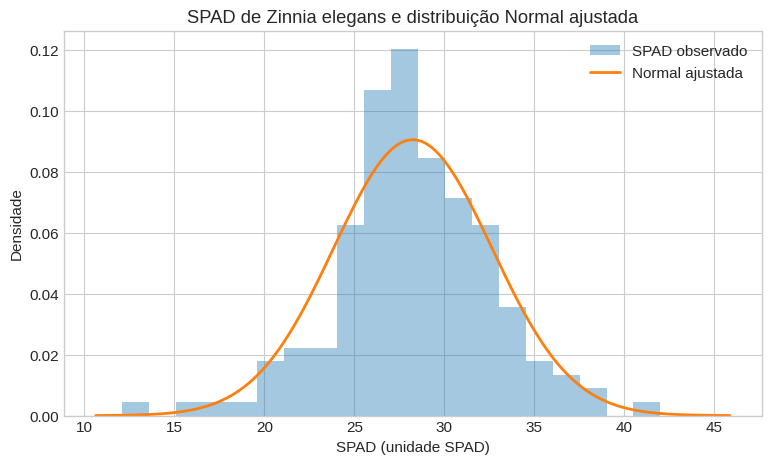

In [ ]:
# Histograma dos dados e curva Normal ajustada

x = np.linspace(
    mu_Z - 4 * sd_Z,
    mu_Z + 4 * sd_Z,
    1000
)

y = stats.norm.pdf(
    x,
    loc=mu_Z,
    scale=sd_Z
)

plt.figure(figsize=(9,5))

plt.hist(
    Z,
    bins=20,
    density=True,
    alpha=0.4,
    label="SPAD observado"
)

plt.plot(
    x,
    y,
    linewidth=2,
    label="Normal ajustada"
)

plt.xlabel("SPAD (unidade SPAD)")
plt.ylabel("Densidade")
plt.title("SPAD de Zinnia elegans e distribuição Normal ajustada")
plt.legend()

plt.show()

### Efeito dos parâmetros da distribuição Normal

A distribuição Normal possui dois parâmetros principais: $\mu$ e $\sigma$.

Quando alteramos $\mu$, mantendo $\sigma$.constante, a curva muda de posição, deslocando-se para a esquerda ou para a direita.

Quando aumentamos $\sigma$., mantendo $\mu$ constante, a curva fica mais espalhada e seu pico diminui.

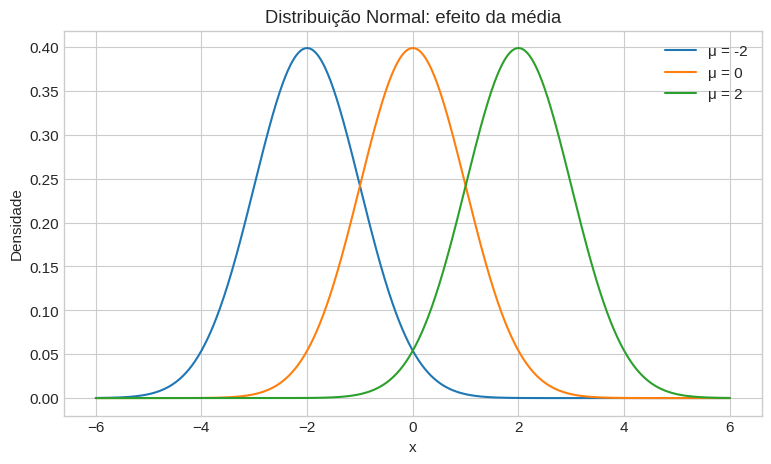

In [ ]:
# Variação da média μ

x = np.linspace(-6, 6, 1000)

plt.figure(figsize=(9,5))

for mu in [-2, 0, 2]:
    plt.plot(
        x,
        stats.norm.pdf(x, loc=mu, scale=1),
        label=f"μ = {mu}"
    )

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Distribuição Normal: efeito da média")
plt.legend()
plt.show()

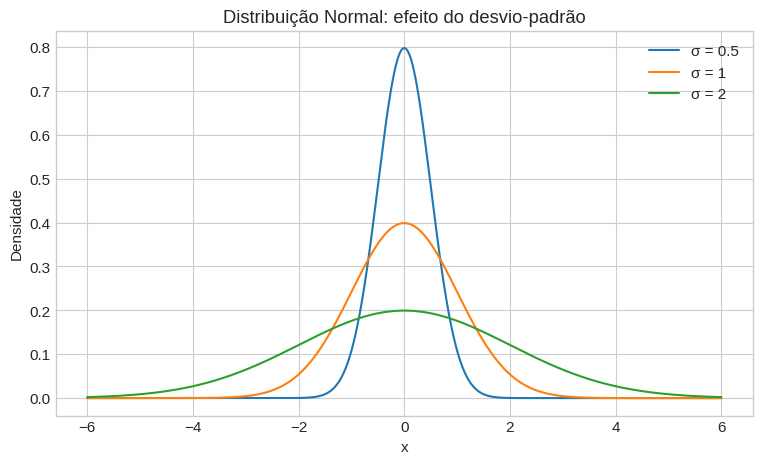

In [ ]:
# Variação do desvio-padrão σ

plt.figure(figsize=(9,5))

for sigma in [0.5, 1, 2]:
    plt.plot(
        x,
        stats.norm.pdf(x, loc=0, scale=sigma),
        label=f"σ = {sigma}"
    )

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Distribuição Normal: efeito do desvio-padrão")
plt.legend()
plt.show()

### Probabilidades utilizando a Normal

Para uma nova folha de *Zinnia elegans*, considerando o modelo Normal ajustado, serão calculadas três probabilidades:

 Probabilidade acumulada:  
   $$P(X \leq 25)$$

 Probabilidade entre dois valores:  
   $$P(25 < X \leq 32)$$

 Probabilidade acima de um valor:  
   $$P(X > 32)$$

Na biblioteca `SciPy`:

- `pdf()` fornece a densidade de probabilidade;
- `cdf()` fornece a probabilidade acumulada;
- `sf()` fornece a probabilidade na cauda superior;
- `ppf()` fornece o quantil ou percentil.

A altura da curva em um ponto (`pdf`) não é uma probabilidade. A probabilidade corresponde à área sob a curva.

In [ ]:
# Probabilidade acumulada

p_acum = stats.norm.cdf(
    25,
    loc=mu_Z,
    scale=sd_Z
)

# Probabilidade entre 25 e 32

p_entre = (
    stats.norm.cdf(32, mu_Z, sd_Z)
    - stats.norm.cdf(25, mu_Z, sd_Z)
)

# Probabilidade acima de 32

p_acima = stats.norm.sf(
    32,
    loc=mu_Z,
    scale=sd_Z
)

print(f"P(X ≤ 25) = {p_acum:.4f}")
print(f"P(25 < X ≤ 32) = {p_entre:.4f}")
print(f"P(X > 32) = {p_acima:.4f}")

P(X ≤ 25) = 0.2306
P(25 < X ≤ 32) = 0.5724
P(X > 32) = 0.1970


In [ ]:
# Percentil 90

percentil_90 = stats.norm.ppf(
    0.90,
    loc=mu_Z,
    scale=sd_Z
)

print(f"Percentil 90 = {percentil_90:.2f} SPAD")

Percentil 90 = 33.89 SPAD


O percentil 90 representa o valor de SPAD abaixo do qual estão aproximadamente 90% dos valores segundo o modelo Normal ajustado. Consequentemente, aproximadamente 10% dos valores esperados pelo modelo estão acima desse valor.

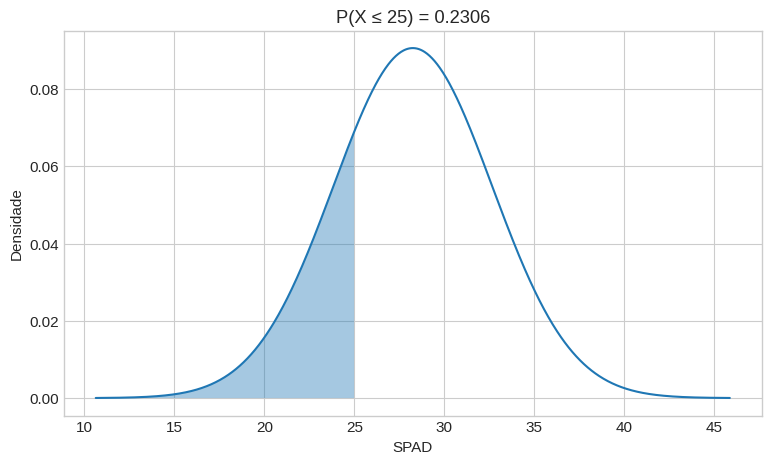

In [ ]:
# Probabilidade P(X ≤ 25)

x = np.linspace(mu_Z - 4*sd_Z, mu_Z + 4*sd_Z, 1000)
y = stats.norm.pdf(x, mu_Z, sd_Z)

plt.figure(figsize=(9,5))

plt.plot(x, y)

xx = x[x <= 25]

plt.fill_between(
    xx,
    stats.norm.pdf(xx, mu_Z, sd_Z),
    alpha=0.4
)

plt.xlabel("SPAD")
plt.ylabel("Densidade")
plt.title(f"P(X ≤ 25) = {p_acum:.4f}")

plt.show()

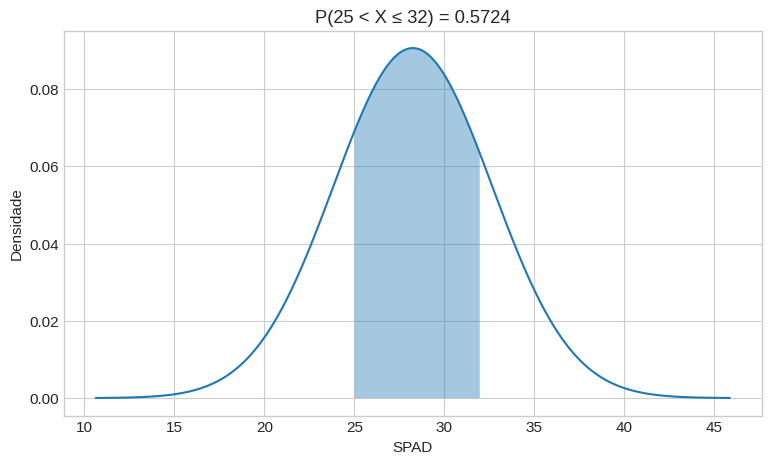

In [ ]:
# Probabilidade P(25 < X ≤ 32)

plt.figure(figsize=(9,5))

plt.plot(x, y)

xx = x[(x >= 25) & (x <= 32)]

plt.fill_between(
    xx,
    stats.norm.pdf(xx, mu_Z, sd_Z),
    alpha=0.4
)

plt.xlabel("SPAD")
plt.ylabel("Densidade")
plt.title(f"P(25 < X ≤ 32) = {p_entre:.4f}")

plt.show()

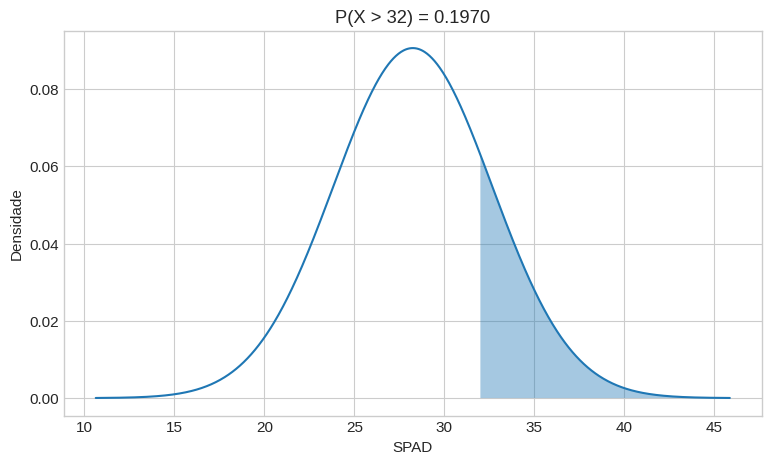

In [ ]:
# Probabilidade P(X > 32)

plt.figure(figsize=(9,5))

plt.plot(x, y)

xx = x[x >= 32]

plt.fill_between(
    xx,
    stats.norm.pdf(xx, mu_Z, sd_Z),
    alpha=0.4
)

plt.xlabel("SPAD")
plt.ylabel("Densidade")
plt.title(f"P(X > 32) = {p_acima:.4f}")

plt.show()

### 3 - Distribuição t de Student

A distribuição t de Student é utilizada principalmente para estimar médias quando o tamanho das amostras é muito pequeno, ou a variância populacional é desconhecida.

Sua função densidade é:

$
f(t)=
\frac{\Gamma\left(\frac{\nu+1}{2}\right)}
{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)}
\left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$

onde:

- $t$ é o valor da estatística;
- $\nu$ representa os graus de liberdade;
- $\Gamma$ representa a função gama.


A distribuição t é simétrica em torno de zero, assemelhando-se à Normal por concentrar seus dados no centro, mas difere-se por apresentar caudas mais pesadas com poucos graus de liberdade (ou seja, valores extremos são um pouco mais prováveis). À medida que esses graus de liberdade aumentam, ela se aproxima da distribuição Normal padrão.


A distribuição t será utilizada para analisar a diferença entre as médias de SPAD de Portulaca grandiflora e Zinnia elegans.


A quantidade modelada é a estatística t, e não os valores individuais de SPAD.

### Fonte

SciPy — distribuição t de Student:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

Referência teórica:

Casella, G.; Berger, R. L. (2002). *Statistical Inference*. 2nd ed. Duxbury.

TRIOLA, Mario F. et al. (1998) Introdução a Estatística. 7th ed. LivrosTécnicos e Científicos Editora S. A. Rio de Janeiro.

In [ ]:
# Estatística t de Welch

nP = len(P)
nZ = len(Z)

meanP = P.mean()
meanZ = Z.mean()

varP = P.var(ddof=1)
varZ = Z.var(ddof=1)

t_obs = (
    (meanP - meanZ)
    /
    np.sqrt(varP/nP + varZ/nZ)
)

# Graus de liberdade de Welch

df_t = (
    (varP/nP + varZ/nZ)**2
    /
    (
        (varP/nP)**2/(nP-1)
        +
        (varZ/nZ)**2/(nZ-1)
    )
)

p_valor = 2 * stats.t.sf(
    abs(t_obs),
    df_t
)

print(f"t observado = {t_obs:.4f}")
print(f"Graus de liberdade = {df_t:.2f}")
print(f"p-valor bilateral = {p_valor:.4f}")

t observado = 0.3249
Graus de liberdade = 220.66
p-valor bilateral = 0.7456


### Interpretação da estatística t

A estatística t mede a diferença entre as médias em relação à incerteza associada às estimativas.

Um valor de t próximo de zero indica que a diferença observada entre as médias é pequena em relação ao erro-padrão.

O teste de Welch é utilizado porque não exige que as duas populações tenham variâncias iguais.

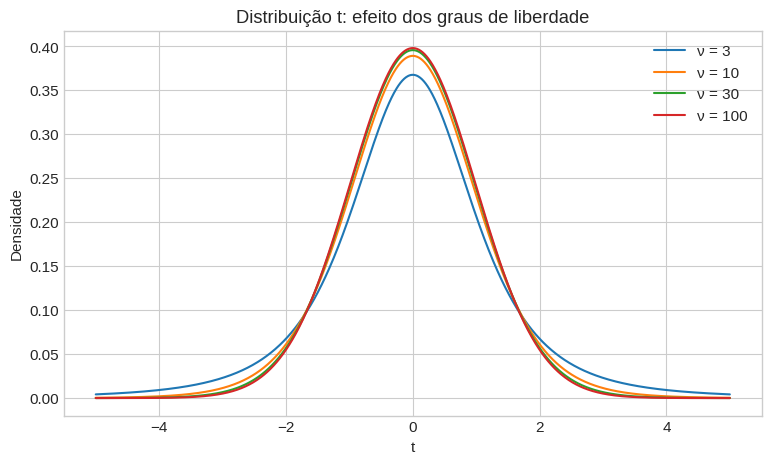

In [ ]:
x = np.linspace(-5, 5, 1000)

plt.figure(figsize=(9,5))

for gl in [3, 10, 30, 100]:
    plt.plot(
        x,
        stats.t.pdf(x, gl),
        label=f"ν = {gl}"
    )

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title("Distribuição t: efeito dos graus de liberdade")
plt.legend()

plt.show()

### Probabilidades utilizando a distribuição t

Considerando a distribuição t com os graus de liberdade calculados pelo método de Welch, serão calculadas:

$
P(T\le1)$

$
P(-1<T\le1)
$

$
P(T>1)$

Essas probabilidades representam áreas da distribuição da estatística t, sob as hipóteses do modelo.

In [ ]:
p_t_acum = stats.t.cdf(1, df_t)

p_t_entre = (
    stats.t.cdf(1, df_t)
    -
    stats.t.cdf(-1, df_t)
)

p_t_acima = stats.t.sf(1, df_t)

percentil_t = stats.t.ppf(
    0.975,
    df_t
)

print(f"P(T ≤ 1) = {p_t_acum:.4f}")
print(f"P(-1 < T ≤ 1) = {p_t_entre:.4f}")
print(f"P(T > 1) = {p_t_acima:.4f}")
print(f"Percentil 97,5% = {percentil_t:.4f}")

P(T ≤ 1) = 0.8408
P(-1 < T ≤ 1) = 0.6816
P(T > 1) = 0.1592
Percentil 97,5% = 1.9708


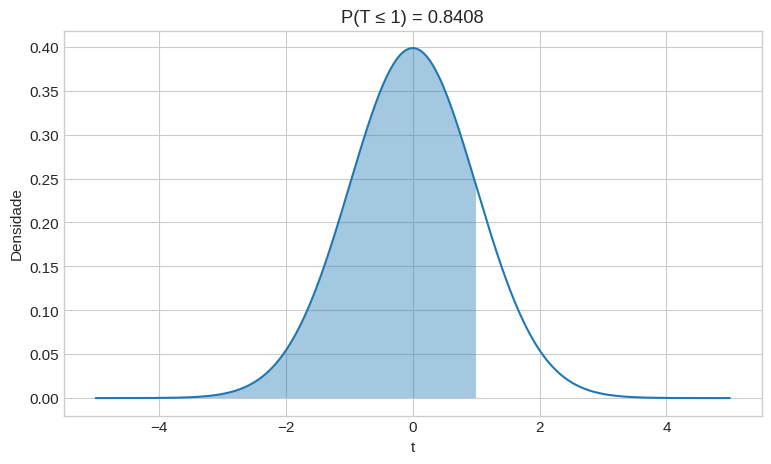

In [ ]:
# Gráfico da probabilidade acumulada

x = np.linspace(-5, 5, 1000)

plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.t.pdf(x, df_t)
)

xx = x[x <= 1]

plt.fill_between(
    xx,
    stats.t.pdf(xx, df_t),
    alpha=0.4
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title(f"P(T ≤ 1) = {p_t_acum:.4f}")

plt.show()

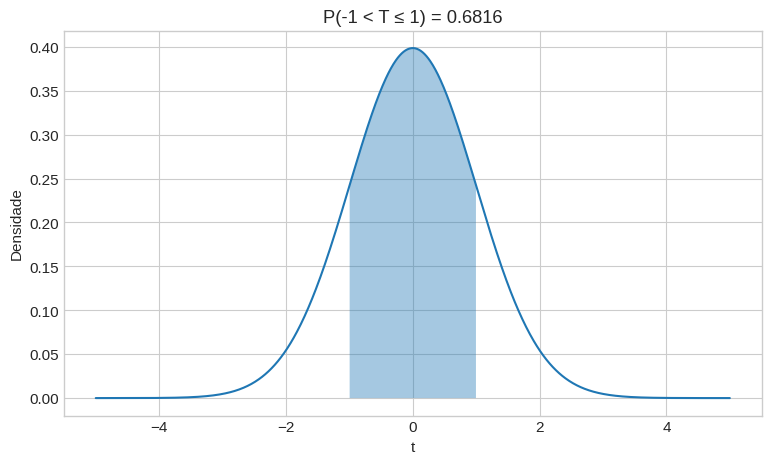

In [ ]:
# Gráfico da probabilidade entre -1 e 1

plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.t.pdf(x, df_t)
)

xx = x[(x >= -1) & (x <= 1)]

plt.fill_between(
    xx,
    stats.t.pdf(xx, df_t),
    alpha=0.4
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title(f"P(-1 < T ≤ 1) = {p_t_entre:.4f}")

plt.show()

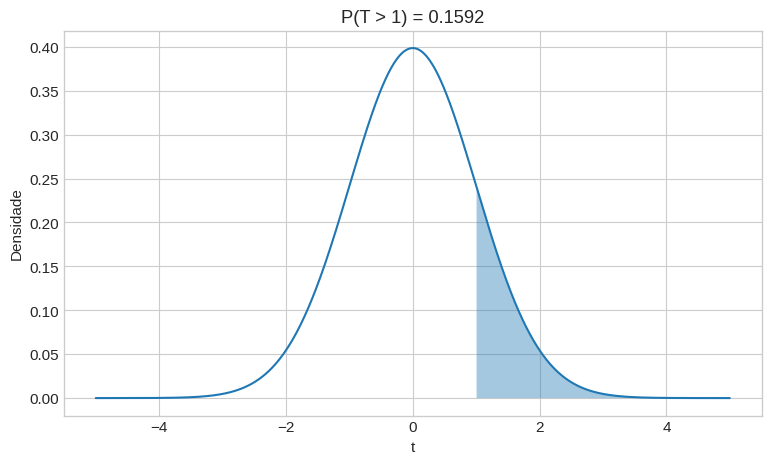

In [ ]:
# Gráfico da probabilidade acima de 1

plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.t.pdf(x, df_t)
)

xx = x[x >= 1]

plt.fill_between(
    xx,
    stats.t.pdf(xx, df_t),
    alpha=0.4
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title(f"P(T > 1) = {p_t_acima:.4f}")

plt.show()

### 4 - Distribuição qui-quadrado

A distribuição qui-quadrado é uma distribuição contínua definida para valores maiores ou iguais a zero, ela surge da soma dos quadrados de variáveis aleatórias independentes com distribuição normal padrão. Diferente das anteriores, a concentração de resultados é deslocado do centro, assimétrica à direita (positivamente assimétrica), mas conforme o número de graus de liberdade aumenta, a curva se torna mais simétrica e se aproxima de uma distribuição Normal.

Sua função densidade é:

$
f(x)=
\frac{1}{2^{\nu/2}\Gamma(\nu/2)}
x^{\nu/2-1}e^{-x/2}
$

para $x>0$ e $\nu>0$.

O parâmetro $\nu$ representa os graus de liberdade.

### Aplicação à variância

Se uma amostra aleatória é proveniente de uma população Normal com variância verdadeira $\sigma_0^2$, então:

$
\chi^2 =
\frac{(n-1)S^2}{\sigma_0^2}
$

segue uma distribuição qui-quadrado com $n-1$ graus de liberdade.

Nesta análise, a variância de *Portulaca grandiflora* será utilizada como uma variância de referência para ilustrar essa relação.

Isso é uma aplicação didática: não estamos afirmando que a variância de P seja uma variância populacional conhecida.

### Fonte

SciPy — distribuição qui-quadrado:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

Referência teórica:

Casella, G.; Berger, R. L. (2002). *Statistical Inference*. 2nd ed. Duxbury.

Stern, R. B. 2022. Propriedades de variáveis aleatórias. Distribuições normal, chi-quadrado e F. Disponível em: https://www.rafaelstern.science/courses/intro_stat/aulas/06_distribuicoes/ acessado em: 05/10/2026

In [ ]:
# Estatística qui-quadrado

df_chi = nZ - 1

# Variância de referência
sigma0_2 = varP

# Estatística para a variância de Z
chi_obs = (
    (nZ - 1) * varZ
    /
    sigma0_2
)

print(f"Variância de P usada como referência = {sigma0_2:.4f}")
print(f"Variância de Z = {varZ:.4f}")
print(f"Graus de liberdade = {df_chi}")
print(f"Qui-quadrado observado = {chi_obs:.4f}")

Variância de P usada como referência = 75.6908
Variância de Z = 19.3967
Graus de liberdade = 149
Qui-quadrado observado = 38.1832


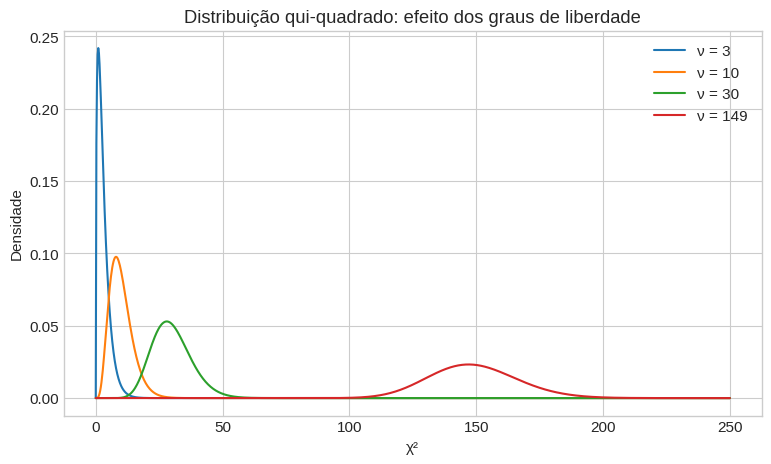

In [ ]:
x = np.linspace(0, 250, 1000)

plt.figure(figsize=(9,5))

for gl in [3, 10, 30, 149]:
    plt.plot(
        x,
        stats.chi2.pdf(x, gl),
        label=f"ν = {gl}"
    )

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title("Distribuição qui-quadrado: efeito dos graus de liberdade")
plt.legend()

plt.show()

### Probabilidades utilizando o qui-quadrado

Considerando uma distribuição qui-quadrado com 149 graus de liberdade, serão calculadas:

$
P(\chi^2\le120)$

$
P(120<\chi^2\le180)
$

$
P(\chi^2>180)$

Essas probabilidades representam áreas sob a distribuição da estatística qui-quadrado.

In [ ]:
p_chi_acum = stats.chi2.cdf(
    120,
    df_chi
)

p_chi_entre = (
    stats.chi2.cdf(180, df_chi)
    -
    stats.chi2.cdf(120, df_chi)
)

p_chi_acima = stats.chi2.sf(
    180,
    df_chi
)

percentil_chi = stats.chi2.ppf(
    0.05,
    df_chi
)

print(f"P(χ² ≤ 120) = {p_chi_acum:.4f}")
print(f"P(120 < χ² ≤ 180) = {p_chi_entre:.4f}")
print(f"P(χ² > 180) = {p_chi_acima:.4f}")
print(f"Percentil 5% = {percentil_chi:.4f}")

P(χ² ≤ 120) = 0.0389
P(120 < χ² ≤ 180) = 0.9186
P(χ² > 180) = 0.0425
Percentil 5% = 121.7870


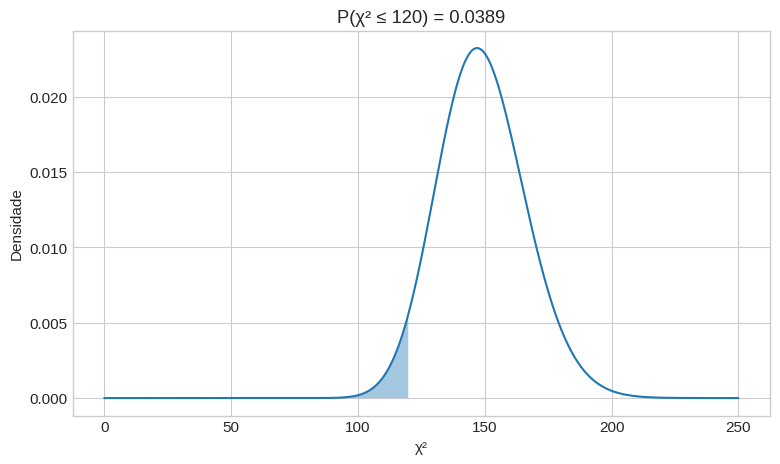

In [ ]:
x = np.linspace(0, 250, 1000)

plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.chi2.pdf(x, df_chi)
)

xx = x[x <= 120]

plt.fill_between(
    xx,
    stats.chi2.pdf(xx, df_chi),
    alpha=0.4
)

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title(f"P(χ² ≤ 120) = {p_chi_acum:.4f}")

plt.show()

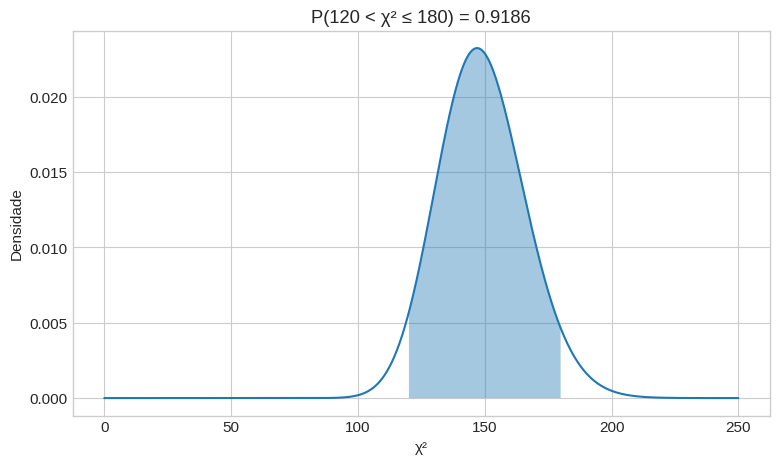

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.chi2.pdf(x, df_chi)
)

xx = x[(x >= 120) & (x <= 180)]

plt.fill_between(
    xx,
    stats.chi2.pdf(xx, df_chi),
    alpha=0.4
)

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title(f"P(120 < χ² ≤ 180) = {p_chi_entre:.4f}")

plt.show()

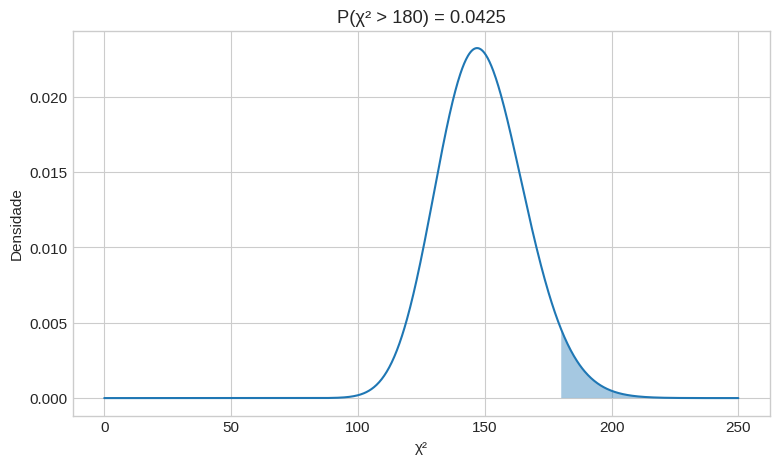

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.chi2.pdf(x, df_chi)
)

xx = x[x >= 180]

plt.fill_between(
    xx,
    stats.chi2.pdf(xx, df_chi),
    alpha=0.4
)

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title(f"P(χ² > 180) = {p_chi_acima:.4f}")

plt.show()

### 5 - Distribuição F de Fisher

A distribuição F é utilizada para representar a razão entre duas variâncias amostrais, ou seja, ela é a razão entre duas variáveis qui-quadrado independentes divididas pelos seus respectivos graus de liberdade. Assim como a distribuição qui-quadrado, a frequência de seus resultados será sempre assimétrica positiva, começando no zero e estendendo-se para valores positivos no eixo horizontal.

Sua função densidade é:

$
f(x)=
\frac{\Gamma\left(\frac{\nu_1+\nu_2}{2}\right)}
{\Gamma\left(\frac{\nu_1}{2}\right)
\Gamma\left(\frac{\nu_2}{2}\right)}
\left(\frac{\nu_1}{\nu_2}\right)^{\nu_1/2}
\frac{x^{\nu_1/2-1}}
{\left(1+\frac{\nu_1}{\nu_2}x\right)^{(\nu_1+\nu_2)/2}}
$

para $x>0$.

Os parâmetros são:

- $\nu_1$: graus de liberdade do numerador;
- $\nu_2$: graus de liberdade do denominador.

A distribuição F é assimétrica e assume apenas valores positivos.

### Aplicação aos dados

Será calculada a razão entre as variâncias de SPAD:

$
F=
\frac{S_P^2}{S_Z^2}
$

Assim, valores de F maiores que 1 indicam que a variância do numerador é maior que a do denominador.

A distribuição F representa a distribuição da razão entre variâncias sob determinadas hipóteses, e não a probabilidade de uma espécie ser biologicamente “mais variável”.

### Fonte

SciPy — distribuição F:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

Referência teórica:

Casella, G.; Berger, R. L. (2002). *Statistical Inference*. 2nd ed. Duxbury.

Cruz, J. P. 2019. Distribuição F de Fisher. Distribuição de amostragem. Disponível em: https://sweet.ua.pt/pedrocruz/bioestatistica/da-fisher.html#gsc.tab=0 Acessado em: 05/10/2026.

In [ ]:
# Razão das variâncias

df1 = nP - 1
df2 = nZ - 1

F_obs = varP / varZ

p_F = stats.f.sf(
    F_obs,
    df1,
    df2
)

print(f"Variância de P = {varP:.4f}")
print(f"Variância de Z = {varZ:.4f}")

print(f"\nF observado = {F_obs:.4f}")

print(f"Graus de liberdade do numerador = {df1}")
print(f"Graus de liberdade do denominador = {df2}")

print(f"\nP(F ≥ F observado) = {p_F:.6g}")

Variância de P = 75.6908
Variância de Z = 19.3967

F observado = 3.9022
Graus de liberdade do numerador = 149
Graus de liberdade do denominador = 149

P(F ≥ F observado) = 5.9377e-16


### Efeito dos graus de liberdade na distribuição F

A distribuição F possui dois graus de liberdade:

- $\nu_1$: graus de liberdade do numerador;
- $\nu_2$: graus de liberdade do denominador.

O enunciado solicita que esses parâmetros sejam investigados separadamente.

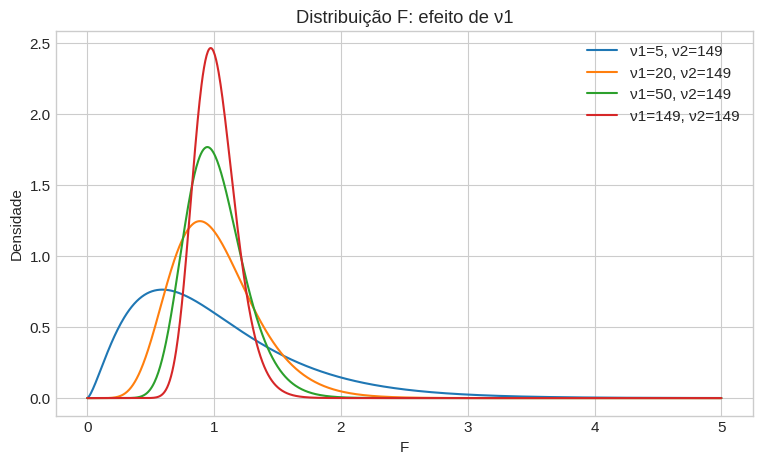

In [ ]:
# Variando os graus de liberdade do numerador

x = np.linspace(0, 5, 1000)

plt.figure(figsize=(9,5))

for gl1 in [5, 20, 50, 149]:
    plt.plot(
        x,
        stats.f.pdf(x, gl1, 149),
        label=f"ν1={gl1}, ν2=149"
    )

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Distribuição F: efeito de ν1")
plt.legend()

plt.show()

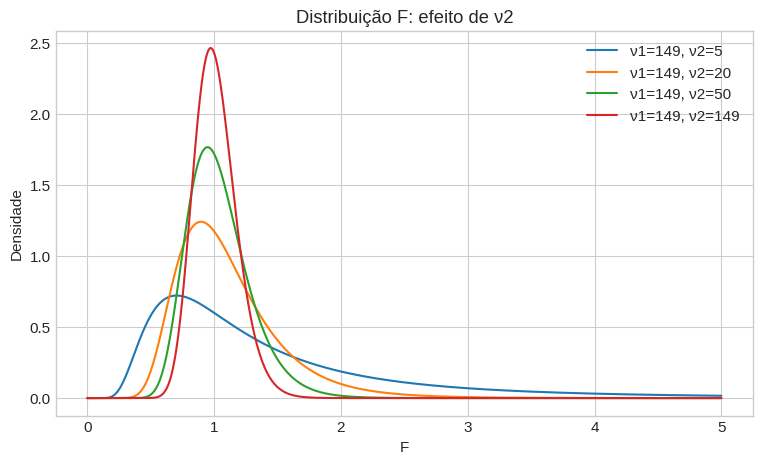

In [ ]:
# Variando os graus de liberdade do denominador

plt.figure(figsize=(9,5))

for gl2 in [5, 20, 50, 149]:
    plt.plot(
        x,
        stats.f.pdf(x, 149, gl2),
        label=f"ν1=149, ν2={gl2}"
    )

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Distribuição F: efeito de ν2")
plt.legend()

plt.show()

### Probabilidades utilizando a distribuição F

Para uma distribuição F com 149 graus de liberdade no numerador e no denominador, serão calculadas:

$
P(F\le0,75)
$

$
P(0,75<F\le1,5)
$

$
P(F>1,5)
$

Também será analisada a área acima do valor F observado.

Essas probabilidades se referem à razão de variâncias como estatística, e não diretamente aos valores de SPAD das folhas.

In [ ]:
p_F_acum = stats.f.cdf(
    0.75,
    df1,
    df2
)

p_F_entre = (
    stats.f.cdf(1.5, df1, df2)
    -
    stats.f.cdf(0.75, df1, df2)
)

p_F_acima = stats.f.sf(
    1.5,
    df1,
    df2
)

percentil_F = stats.f.ppf(
    0.95,
    df1,
    df2
)

print(f"P(F ≤ 0,75) = {p_F_acum:.4f}")
print(f"P(0,75 < F ≤ 1,5) = {p_F_entre:.4f}")
print(f"P(F > 1,5) = {p_F_acima:.4f}")
print(f"Percentil 95% = {percentil_F:.4f}")

P(F ≤ 0,75) = 0.0401
P(0,75 < F ≤ 1,5) = 0.9530
P(F > 1,5) = 0.0069
Percentil 95% = 1.3104


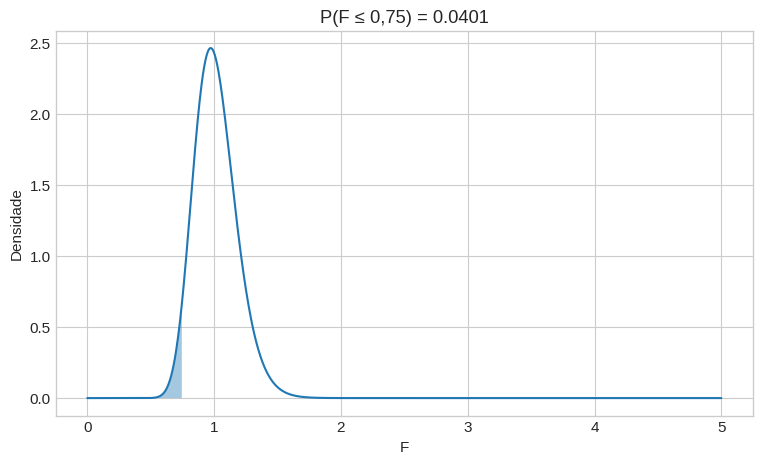

In [ ]:
x = np.linspace(0, 5, 1000)

plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.f.pdf(x, df1, df2)
)

xx = x[x <= 0.75]

plt.fill_between(
    xx,
    stats.f.pdf(xx, df1, df2),
    alpha=0.4
)

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title(f"P(F ≤ 0,75) = {p_F_acum:.4f}")

plt.show()

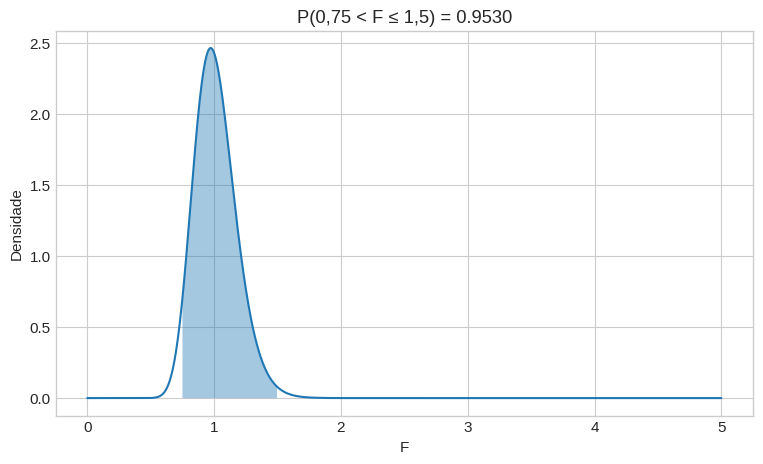

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.f.pdf(x, df1, df2)
)

xx = x[(x >= 0.75) & (x <= 1.5)]

plt.fill_between(
    xx,
    stats.f.pdf(xx, df1, df2),
    alpha=0.4
)

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title(f"P(0,75 < F ≤ 1,5) = {p_F_entre:.4f}")

plt.show()

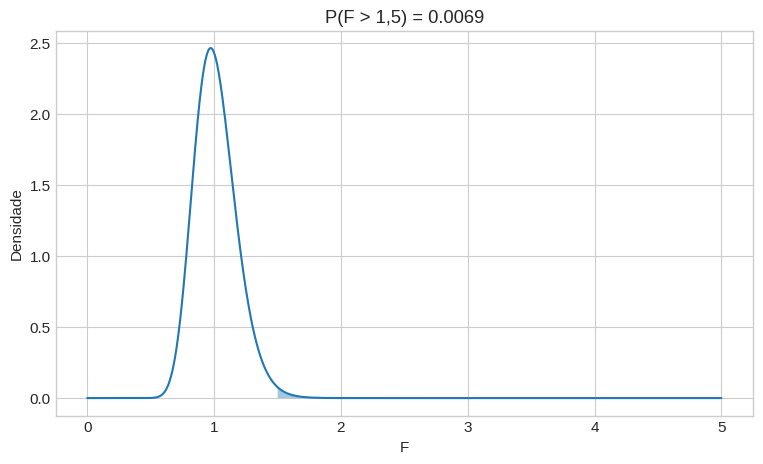

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.f.pdf(x, df1, df2)
)

xx = x[x >= 1.5]

plt.fill_between(
    xx,
    stats.f.pdf(xx, df1, df2),
    alpha=0.4
)

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title(f"P(F > 1,5) = {p_F_acima:.4f}")

plt.show()

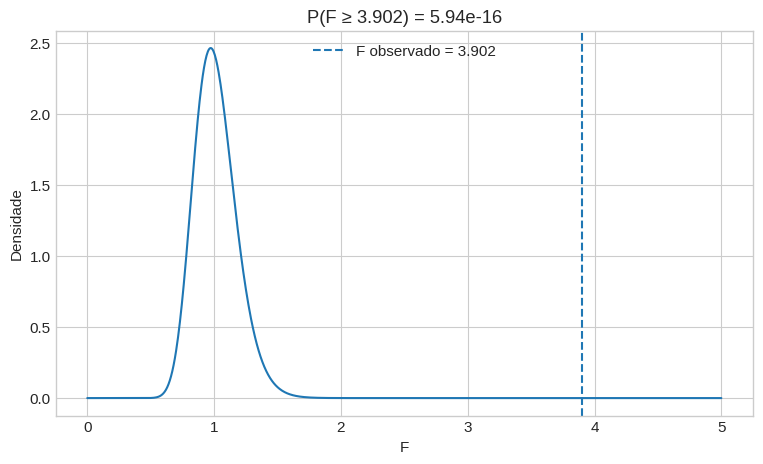

In [ ]:
# Área acima do F observado

plt.figure(figsize=(9,5))

plt.plot(
    x,
    stats.f.pdf(x, df1, df2)
)

xx = x[x >= F_obs]

plt.fill_between(
    xx,
    stats.f.pdf(xx, df1, df2),
    alpha=0.4
)

plt.axvline(
    F_obs,
    linestyle="--",
    label=f"F observado = {F_obs:.3f}"
)

plt.xlabel("F")
plt.ylabel("Densidade")

plt.title(
    f"P(F ≥ {F_obs:.3f}) = {p_F:.3g}"
)

plt.legend()

plt.show()

### Interpretação da distribuição F

A razão entre as variâncias observadas foi aproximadamente:

$
F=\frac{S_P^2}{S_Z^2}\approx3,90
$

Isso significa que a variância amostral do SPAD de *Portulaca grandiflora* foi aproximadamente 3,9 vezes a variância observada em *Zinnia elegans* no subconjunto analisado.

A distribuição F permite avaliar quão extrema seria uma razão de variâncias desse tamanho sob as hipóteses do modelo.

É importante não interpretar a área sob a curva F como a probabilidade de que uma espécie tenha “mais variabilidade”. A área representa a probabilidade de obter determinado valor da estatística F sob o modelo assumido.

Além disso, a independência das folhas é uma limitação importante, pois várias folhas pertencem à mesma parcela.

### 6 - Comparação entre as quatro distribuições

| Distribuição | Quantidade modelada | Parâmetros principais | Aplicação no trabalho |
|---|---|---|---|
| Normal | SPAD de uma folha | $\mu$ e $\sigma$ | Modelo aproximado para uma medida contínua |
| t de Student | Estatística t | Graus de liberdade | Comparação entre médias |
| Qui-quadrado | Estatística associada à variância | Graus de liberdade | Análise de uma variância amostral |
| F de Fisher | Razão entre variâncias | $\nu_1$ e $\nu_2$ | Comparação da variabilidade entre grupos |

A principal diferença conceitual é que o SPAD é uma medida biológica observada, enquanto t, qui-quadrado e F são distribuições utilizadas para modelar estatísticas calculadas a partir das amostras.

Portanto, não afirmamos que as folhas possuem distribuição t, qui-quadrado ou F.

### 7 - Conclusão

A utilização da base de dados real do Dryad permitiu aplicar quatro distribuições de probabilidade a uma situação biológica envolvendo características foliares.

A distribuição Normal foi utilizada como modelo aproximado para os valores individuais de SPAD de *Zinnia elegans*. As probabilidades calculadas representam possíveis valores de uma nova folha sob o modelo assumido.

A distribuição t de Student foi utilizada para modelar a estatística associada à comparação entre as médias de SPAD de *Portulaca grandiflora* e *Zinnia elegans*. A estatística observada foi próxima de zero, indicando uma diferença pequena entre as médias em relação ao erro-padrão.

A distribuição qui-quadrado foi utilizada para representar uma estatística associada à variância amostral. Essa distribuição permite estudar como uma variância estimada pode se comportar sob determinadas condições.

A distribuição F de Fisher foi utilizada para representar a razão entre as variâncias de SPAD das duas espécies. A razão observada foi aproximadamente 3,90, indicando maior variabilidade de SPAD em *Portulaca grandiflora* no subconjunto analisado.

Apesar dos resultados, existem limitações importantes. As folhas estão agrupadas dentro de parcelas e, portanto, não são completamente independentes. Além disso, a análise considera apenas ambiente ambiente e monoculturas de duas das três espécies disponíveis na base.

Assim, os resultados devem ser interpretados como uma aplicação das distribuições de probabilidade aos dados reais e não como uma conclusão ecológica definitiva sobre as espécies.

### 8 -  Referências

### Base de dados

Dryad. *Trait variation and plant performance: Interactive effects of diversity and spatial patterning of plants across environmental conditions.*

DOI: https://doi.org/10.5061/dryad.w6m905r2n

### Documentação SciPy

Distribuição Normal:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.Normal.html

Distribuição t de Student:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

Distribuição qui-quadrado:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

Distribuição F de Fisher:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

### Referência teórica

Casella, G.; Berger, R. L. (2002). *Statistical Inference*. 2nd ed. Duxbury.

Meyer, F. P. Distribuição Normal (Gaussiana). Distribuição Normal. Disponível em: https://www.inf.ufsc.br/~andre.zibetti/probabilidade/normal.html Acessado em: 03/10/2026.

TRIOLA, Mario F. et al. (1998) Introdução a Estatística. 7th ed. LivrosTécnicos e Científicos Editora S. A. Rio de Janeiro.


Stern, R. B. 2022. Propriedades de variáveis aleatórias. Distribuições normal, chi-quadrado e F. Disponível em: https://www.rafaelstern.science/courses/intro_stat/aulas/06_distribuicoes/ acessado em: 05/10/2026.

Cruz, J. P. 2019. Distribuição F de Fisher. Distribuição de amostragem. Disponível em: https://sweet.ua.pt/pedrocruz/bioestatistica/da-fisher.html#gsc.tab=0 Acessado em: 05/10/2026.